<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia


# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

pd.set_option('display.max_columns', None)

## **0.2 Global Configuration**

In [2]:
DATA_DIR = 'Dataset' 
timestamp_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

df = pd.read_csv(f'../{DATA_DIR}/Cleaned Data/cleaned.csv', parse_dates=timestamp_columns)
delivered = df[df["order_status"]=="delivered"]
unique = delivered.drop_duplicates(subset='order_id', keep='first').reset_index(drop=True)

pd.set_option('display.max_columns', None)
print(f"Dataframe size: {df.shape}")
print(f"Delivered Dataframe size: {delivered.shape}")
print(f"Unique Dataframe size: {unique.shape}")

Dataframe size: (111777, 39)
Delivered Dataframe size: (108566, 39)
Unique Dataframe size: (95070, 39)


# **Section 1: Data Analysis**

## **1.1 what cause the late delivery**

In [3]:
unique['is_late'] = unique['order_delivered_customer_date'] > unique['order_estimated_delivery_date']

### **1.1.1 Seller being late to give the package before the `shipping_limit_date`**

In [4]:
print(f"Total of late delivery with the seller sending the package to olist late: {len(unique[(unique['is_late']==True)&(unique["shipping_limit_date"]<unique["order_delivered_carrier_date"])])}")
print(f"Percentage of late delivery with the seller sending the package to olist late against all order which is late: {(len(unique[(unique['is_late']==True)&(unique["shipping_limit_date"]<unique["order_delivered_carrier_date"])]))/(len(unique[unique['is_late']==True]))*100:.2f}%")

Total of late delivery with the seller sending the package to olist late: 2127
Percentage of late delivery with the seller sending the package to olist late against all order which is late: 27.30%


As the late delivery that have problem in which the seller send the package to olist outside of the regulated date for shipping limit only around 27.30% we cannot conclude that the main problem in which the delivery was late is caused by the package was shipped late to olist.

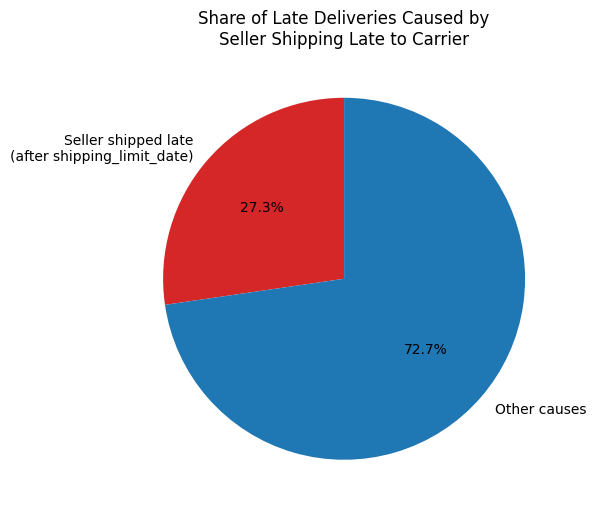

In [5]:
seller_late_count = len(unique[(unique['is_late']==True)&(unique["shipping_limit_date"]<unique["order_delivered_carrier_date"])])
total_late = unique['is_late'].sum()
other_late = total_late - seller_late_count

fig, ax = plt.subplots(figsize=(6, 6))
labels = ['Seller shipped late\n(after shipping_limit_date)', 'Other causes']
sizes = [seller_late_count, other_late]
colors = ['#d62728', '#1f77b4']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Share of Late Deliveries Caused by\nSeller Shipping Late to Carrier')
plt.tight_layout()
plt.show()

### **1.1.2 `payment_type` used for the late order**

In [6]:
columns = unique['payment_type'].unique()
index = ["Late", "On-Time"]
late = []
on_time = []

for i in columns:
    late.append(unique[(unique['is_late']==True)&(unique['payment_type']==i)]['order_id'].count())
    on_time.append(unique[(unique['is_late']==False)&(unique['payment_type']==i)]['order_id'].count())

data = np.array([late, on_time])

df_summary = pd.DataFrame(data, index=index, columns=columns)

print("--- Contingency Table ---")
print(df_summary)

--- Contingency Table ---
         credit_card  boleto  debit_card  voucher
Late            5873    1699         114      104
On-Time        67392   17185        1325     1378


Having analyzed the data distribution, our next step is to determine if `payment_type` correlates with late orders. We will conduct a **Chi-Square Test** to evaluate if this relationship is statistically significant.

In [7]:
chi2, p_val, dof, expected = stats.chi2_contingency(df_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 22.1383
p-value: 0.000061
Degrees of Freedom: 3


With a Chi-Square p-value of **0.000061**, we have confirmed a significant correlation between payment types and delivery delays. Consequently, a deeper post-hoc test using **Z-scores (Adjusted Standardized Residuals)** is required to pinpoint exactly which payment methods are causing the problem.

In [8]:
n = data.sum()

row_totals = df_summary.sum(axis=1).values[:, np.newaxis]  
col_totals = df_summary.sum(axis=0).values 

r_prop = row_totals / n
c_prop = col_totals / n

se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))

z_scores_matrix = (df_summary.values - expected) / se
z_scores = pd.DataFrame(z_scores_matrix, index=index, columns=columns)

print("--- Adjusted Residuals (Z-Scores) ---")
print(z_scores.round(2))

--- Adjusted Residuals (Z-Scores) ---
         credit_card  boleto  debit_card  voucher
Late           -3.67    4.49       -0.38    -1.66
On-Time         3.67   -4.49        0.38     1.66


To determine which payment methods contribute most to delivery delays, we evaluated the Z-scores against the critical thresholds of ±1.96 (representing a standard 95% confidence level for a two-tailed test). Scores falling outside this range indicate a statistically significant deviation from the baseline.  
  
Based on the adjusted standardized residuals for late deliveries, we can draw the following conclusions:  
- **Boleto (4.49)**: Significantly exceeds +1.96, confirming that Boleto payments are heavily overrepresented in late deliveries.
- **Credit Card (-3.67)**: Falls well below -1.96, proving that credit card transactions are significantly less likely to experience delays.
- **Debit Card (-0.38) & Voucher (-1.66)**: Both scores fall within the ±1.96 threshold, indicating their variations are statistically insignificant and have no measurable impact on delivery lateness.

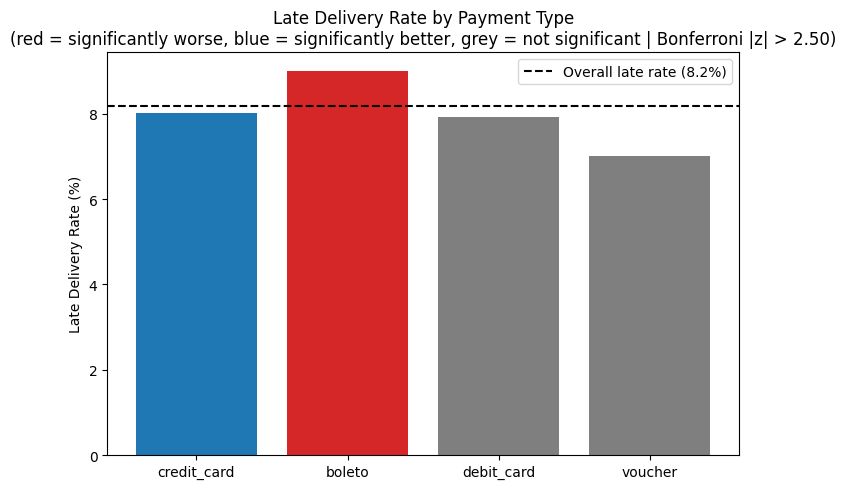

In [9]:
late_rate = (df_summary.loc['Late'] / df_summary.sum()) * 100
overall_late_rate = unique['is_late'].mean() * 100
z_vals = z_scores.loc['Late']
k = len(df_summary.columns) 
z_crit = stats.norm.ppf(1 - 0.05 / (2 * k)) 
sig = z_vals.abs() > z_crit
colors = ['#d62728' if (s and z > 0) else ('#1f77b4' if (s and z < 0) else '#7f7f7f') for s, z in zip(sig, z_vals)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(late_rate.index, late_rate.values, color=colors)
ax.axhline(overall_late_rate, color='black', linestyle='--', label=f'Overall late rate ({overall_late_rate:.1f}%)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title(f'Late Delivery Rate by Payment Type\n(red = significantly worse, blue = significantly better, grey = not significant | Bonferroni |z| > {z_crit:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

### **1.1.3 `payment_installments` on late delivery**

In [10]:
unique["payment_installments"].unique()
print(f'Highest Payment Installment: {unique["payment_installments"].max()}')
print(f'Lowest Payment Installment: {unique["payment_installments"].min()}')
print(f"the 75% cutoff value in payment installment are: {unique["payment_installments"].quantile(0.7)}")

Highest Payment Installment: 24.0
Lowest Payment Installment: 0.0
the 75% cutoff value in payment installment are: 3.0


To ensure an equitable analysis and address data sparsity (such as high-tier installment plans occurring only once) we will bin the payment_installments variable. Aggregating these frequencies into standardized business tiers optimizes cell counts for statistical testing and enhances the validity of our findings. The data will be catagorized into these levels:  
| Bin Name | Installment Range | What it actually represents |
|---|---|---|
| Instant Cash/Upfront | - | Non-credit payments (Boleto, Debit, Voucher). |
| Credit Upfront | 1 | Credit card users who chose to pay the full balance in one cycle. |
| Short-Term | 2 - 4 | Split financing over a brief 2–4 month window. |
| Mid-Term | 5 - 10 | Extended payment plans (heavily concentrated at 6 and 10 months). |
| Long-Term | 11 - 24 | Long-term high-value financing (1 to 2 years). |

In [11]:
bins = [-1, 1, 4, 10, 24]
labels = ['Credit Upfront', 'Short-Term', 'Mid-Term', 'Long-Term']

unique['installment_group'] = pd.cut(df['payment_installments'], bins=bins, labels=labels)

unique['installment_group'] = unique['installment_group'].cat.add_categories(['Instant Cash/Upfront'])

unique.loc[unique['payment_type'] != 'credit_card', 'installment_group'] = 'Instant Cash/Upfront'

Now that we have categorized them into splitted category what we would do is to check the distribution for the credit installment.

In [12]:
columns = unique['installment_group'].unique()
index = ["Late", "On-Time"]
late = []
on_time = []

for i in columns:
    late.append(unique[(unique['is_late']==True)&(unique['installment_group']==i)]['order_id'].count())
    on_time.append(unique[(unique['is_late']==False)&(unique['installment_group']==i)]['order_id'].count())

data = np.array([late, on_time])

df_summary = pd.DataFrame(data, index=index, columns=columns)

print("--- Contingency Table ---")
print(df_summary)

--- Contingency Table ---
         Credit Upfront  Instant Cash/Upfront  Short-Term  Mid-Term  Long-Term
Late               2792                  1917        1721      1337         23
On-Time           32295                 19888       19832     15010        255


Having analyzed the data distribution, our next step is to determine if `installment_group` that is only used credit correlates with late orders. We will conduct a **Chi-Square Test** to evaluate if this relationship is statistically significant.

In [13]:
chi2, p_val, dof, expected = stats.chi2_contingency(df_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 14.2214
p-value: 0.006621
Degrees of Freedom: 4


With a Chi-Square p-value of **0.006621**, we have confirmed a significant correlation between payment installment and delivery delays. and for that reason a deeper post-hoc test using **Z-scores (Adjusted Standardized Residuals)** is required to pinpoint exactly which payment methods are causing the problem.

In [14]:
n = data.sum()

row_totals = df_summary.sum(axis=1).values[:, np.newaxis]  
col_totals = df_summary.sum(axis=0).values 

r_prop = row_totals / n
c_prop = col_totals / n

se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))

z_scores_matrix = (df_summary.values - expected) / se
z_scores = pd.DataFrame(z_scores_matrix, index=index, columns=columns)

print("--- Adjusted Residuals (Z-Scores) ---")
print(z_scores.round(2))

--- Adjusted Residuals (Z-Scores) ---
         Credit Upfront  Instant Cash/Upfront  Short-Term  Mid-Term  Long-Term
Late              -2.03                  3.67       -1.27     -0.08       0.05
On-Time            2.03                 -3.67        1.27      0.08      -0.05


Based on the adjusted standardized residuals for late deliveries, we can draw the following conclusions:  
- **Instant Cash/Upfront (3.67)**: Significantly exceeds +1.96, confirming that instant cash or upfront payments are heavily overrepresented in late deliveries.
- **Credit Upfront (-2.03)**: Falls below -1.96, proving that credit upfront transactions are significantly less likely to experience delays.
- **Short-Term (-1.27), Mid-Term (-0.08), and Long-Term (0.05)**: All scores fall well within the ±1.96 threshold, indicating their variations are statistically insignificant and have no measurable impact on delivery lateness.  
  
The adjusted residuals support our earlier findings that credit is not the driving factor behind late deliveries, whereas cash-like transactions (resembling Boleto payments) are. Furthermore, this analysis provides deeper insight into credit card behavior: the previously observed trend where credit card transactions are significantly less likely to experience delays holds true specifically when the payment is completed upfront in a single installment cycle.

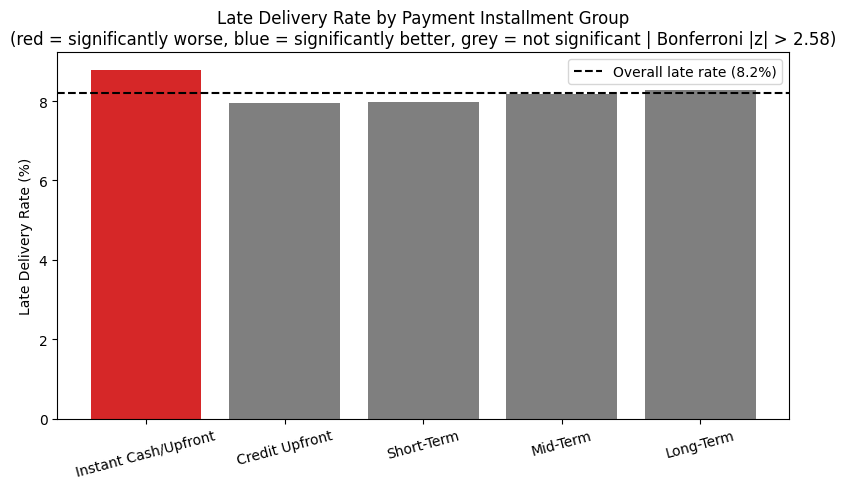

In [15]:
late_rate = (df_summary.loc['Late'] / df_summary.sum()) * 100
overall_late_rate = unique['is_late'].mean() * 100
sig = z_scores.loc['Late'].abs() > 1.96
order = ['Instant Cash/Upfront', 'Credit Upfront', 'Short-Term', 'Mid-Term', 'Long-Term']
late_rate = late_rate.reindex(order)
k = len(df_summary.columns)
z_crit = stats.norm.ppf(1 - 0.05 / (2 * k))
z_vals = z_scores.loc['Late'].reindex(order)
sig = z_vals.abs() > z_crit
colors = ['#d62728' if (s and z > 0) else ('#1f77b4' if (s and z < 0) else '#7f7f7f') for s, z in zip(sig, z_vals)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(late_rate.index, late_rate.values, color=colors)
ax.axhline(overall_late_rate, color='black', linestyle='--', label=f'Overall late rate ({overall_late_rate:.1f}%)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title(f'Late Delivery Rate by Payment Installment Group\n(red = significantly worse, blue = significantly better, grey = not significant | Bonferroni |z| > {z_crit:.2f})')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### **1.1.4 True Physical Distance on late delivery**

The data right now doesnt have the distance between seller and customer, for that reason we would calculate the true physical distance between them using the central latitude and longtitude of each zipcode. to get this true distance what we would do is implement a formula called **Haversine Formula**. This formula would determines the great-circle distance between two points on a sphere given their longitudes and latitudes.  
$$
\begin{aligned}
\text{hav}\theta & = \text{hav}(\Delta\varphi) + \cos(\varphi_1)\cos(\varphi_2)\text{hav}(\Delta\lambda)\\
                 & = \text{hav}(\Delta\varphi) + (1-\text{hav}(\Delta\varphi)-\text{hav}(2\varphi_m))\cdot\text{hav}(\Delta\lambda)\\
                 & =\sin^2\left(\frac{\Delta\varphi}{2}\right) + \left(1-\sin^2\left(\frac{\Delta\varphi}{2}-\sin^2(\varphi_m)\right)\right)\cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \sin^2\left(\frac{\Delta\varphi}{2}\right) + \cos\varphi_1 \cdot \cos\varphi_2 \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \sin^2\left(\frac{\Delta\varphi}{2}\right) \cdot \cos^2\left(\frac{\Delta\lambda}{2}\right) + \cos^2(\varphi_m) \cdot \sin^2\left(\frac{\Delta\lambda}{2}\right)\\
                 & = \frac{1-cos(\Delta\varphi) + \cos\varphi_1 \cdot \cos\varphi_2 \cdot (1-cos(\Delta\lambda))}{2}\\
               c & = 2\cdot\arcsin(\sqrt{\text{hav}\theta})\\
               d & = R\cdot c
\end{aligned}
$$
**Where:**
- $\varphi_1, \lambda_1$ = Coordinates of Point 1 (e.g., Seller)
- $\varphi_2, \lambda_2$ = Coordinates of Point 2 (e.g., Customer)
- $\Delta \varphi = \varphi_2 - \varphi_1$ (Difference in latitude)
- $\Delta \lambda = \lambda_2 - \lambda_1$ (Difference in longitude)
- $\varphi_m$ = Mean latitude between the two points
- $R$ = Earth's radius. Typically 6,371 km for kilometers (or 3,956 miles if you need imperial).


**The Core Concept (Step-by-Step Breakdown)**  
If you look at the math, the formula does three fundamental things:  
- **Converts Degrees to Radians:** Raw GPS data is in decimal degrees (e.g., São Paulo is roughly -23.55, -46.63). Standard trigonometric functions in programming languages (`math.sin`, `np.cos`) expect angles in radians. The formula multiplies degrees by $\frac{\pi}{180}$ first.  
- **Calculates the Haversine of the Central Angle ($\text{hav}\theta$):** The equation solves for the haversine of the angular distance between the two points. The $\cos\varphi_1 \cdot \cos\varphi_2$ modifier adjusts for the fact that lines of longitude ($\lambda$) get closer together as you move away from the equator toward the poles, factoring in the mean latitude ($\varphi_m$).  
- **Finds the Central Angle ($\theta$) and Scales to Earth:** Once $\text{hav}\theta$ is known, you extract the central angle $\theta$ (the angular distance along the surface curve of the sphere). Multiplying this angle by the Earth’s radius ($R$) gives you the actual distance over the curve.



In [16]:
def calculate_haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    r_earth = 6371
    return r_earth * c

In [17]:
unique["delivery_distance_km"] = calculate_haversine(unique["seller_lng"], unique["seller_lat"], unique["customer_lng"], unique["customer_lat"])
unique.loc[:, ["is_late", "delivery_distance_km"]]

,is_late,delivery_distance_km
0,False,18.576110
1,False,851.495069
2,False,514.410666
3,False,1822.226336
4,False,29.676625
...,...,...
95065,False,69.755064
95066,False,474.120037
95067,False,967.847297
95068,False,370.404482


Now that we have make the true distance between seller and customer for each order what we should do is binning it to check which categories of distance that corelated with late delivery.

In [18]:
bins = [-1, 50, 300, 1000, 7000]
labels = ['Short-Range (<50km)', 'Regional (50-300km)', 'Interregional (300-1000km)', 'Long-Haul (>1000km)']

unique['distance_group'] = pd.cut(unique['delivery_distance_km'], bins=bins, labels=labels)

distance_analysis = unique.groupby('distance_group', observed=False)['is_late'].mean().reset_index()
distance_analysis['is_late'] = distance_analysis['is_late'] * 100
print(distance_analysis)

               distance_group    is_late
0         Short-Range (<50km)   6.523613
1         Regional (50-300km)   6.469031
2  Interregional (300-1000km)   8.115830
3         Long-Haul (>1000km)  11.906328


Now that we have categorized them into splitted category what we would do is to check the distribution for delivery distance group.

In [19]:
columns = unique['distance_group'].unique()
index = ["Late", "On-Time"]
late = []
on_time = []

for i in columns:
    late.append(unique[(unique['is_late']==True)&(unique['distance_group']==i)]['order_id'].count())
    on_time.append(unique[(unique['is_late']==False)&(unique['distance_group']==i)]['order_id'].count())

data = np.array([late, on_time])

df_summary = pd.DataFrame(data, index=index, columns=columns)

print("--- Contingency Table ---")
print(df_summary)

--- Contingency Table ---
         Short-Range (<50km)  Interregional (300-1000km)  Long-Haul (>1000km)  \
Late                     757                        3977                 1810   
On-Time                10847                       45026                13392   

         Regional (50-300km)  
Late                    1246  
On-Time                18015  


Having analyzed the data distribution, our next step is to determine if `distance_group` that is only used credit correlates with late orders. We will conduct a **Chi-Square Test** to evaluate if this relationship is statistically significant.

In [20]:
chi2, p_val, dof, expected = stats.chi2_contingency(df_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 398.1267
p-value: 0.000000
Degrees of Freedom: 3


With a Chi-Square p-value of **0.000000**, we have confirmed a significant correlation between delivery distance and delivery delays. and for that reason a deeper post-hoc test using **Z-scores (Adjusted Standardized Residuals)** is required to pinpoint exactly which distance group are causing the problem.

In [21]:
n = data.sum()

row_totals = df_summary.sum(axis=1).values[:, np.newaxis]  
col_totals = df_summary.sum(axis=0).values 

r_prop = row_totals / n
c_prop = col_totals / n

se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))

z_scores_matrix = (df_summary.values - expected) / se
z_scores = pd.DataFrame(z_scores_matrix, index=index, columns=columns)

print("--- Adjusted Residuals (Z-Scores) ---")
print(z_scores.round(2))

--- Adjusted Residuals (Z-Scores) ---
         Short-Range (<50km)  Interregional (300-1000km)  Long-Haul (>1000km)  \
Late                    -7.0                       -0.91                18.21   
On-Time                  7.0                        0.91               -18.21   

         Regional (50-300km)  
Late                   -9.77  
On-Time                 9.77  


Based on the adjusted standardized residuals for delivery distance categories, we can draw the following conclusions:
- **Long-Haul (>1000km) (18.21)**: Significantly exceeds +1.96, confirming that long-haul routes are heavily overrepresented in late deliveries and carry the highest risk of delay.
- **Interregional (300-1000km) (-0.91)**: Falls well within the ±1.96 threshold, indicating its variation is statistically insignificant and does not meaningfully drive delivery lateness.
- **Short-Range (<50km) (-7.0) and Regional (50-300km) (-9.77)**: Both scores fall drastically below -1.96, proving that shorter, more localized delivery distances are significantly less likely to experience delays and strongly favor on-time performance.

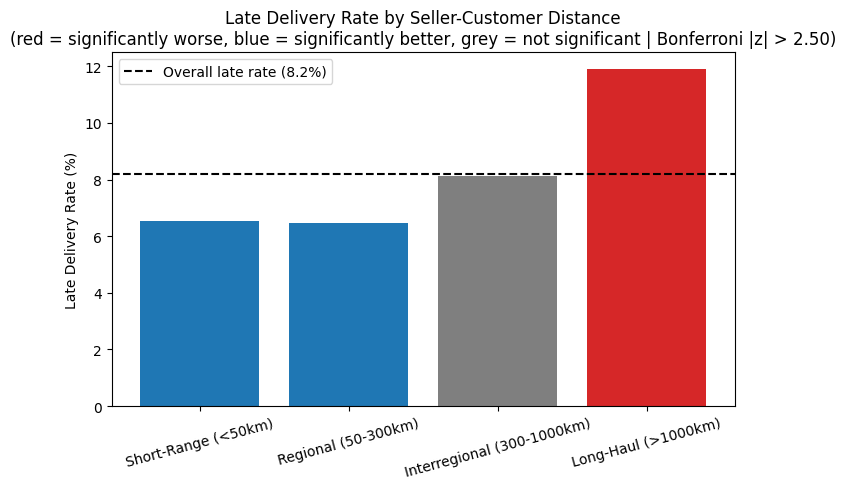

In [22]:
order = distance_analysis['distance_group']
late_rate = distance_analysis.set_index('distance_group')['is_late'].reindex(order)
overall_late_rate = unique['is_late'].mean() * 100
k = len(df_summary.columns)
z_crit = stats.norm.ppf(1 - 0.05 / (2 * k))
z_vals = z_scores.loc['Late'].reindex(order)
sig = z_vals.abs() > z_crit
colors = ['#d62728' if (s and z > 0) else ('#1f77b4' if (s and z < 0) else '#7f7f7f') for s, z in zip(sig, z_vals)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(late_rate.index.astype(str), late_rate.values, color=colors)
ax.axhline(overall_late_rate, color='black', linestyle='--', label=f'Overall late rate ({overall_late_rate:.1f}%)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title(f'Late Delivery Rate by Seller-Customer Distance\n(red = significantly worse, blue = significantly better, grey = not significant | Bonferroni |z| > {z_crit:.2f})')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### **1.1.5 Interstate vs Intrastate orders on late delivery**

In [23]:
unique['is_interstate'] = unique['seller_geo_state'] != unique['customer_geo_state']

Now that we know if the order is an interstate order or not, what we would do is to check the distribution for the order.

In [24]:
columns = unique['is_interstate'].unique()
index = ["Late", "On-Time"]
late = []
on_time = []

for i in columns:
    late.append(unique[(unique['is_late']==True)&(unique['is_interstate']==i)]['order_id'].count())
    on_time.append(unique[(unique['is_late']==False)&(unique['is_interstate']==i)]['order_id'].count())

data = np.array([late, on_time])

df_summary = pd.DataFrame(data, index=index, columns=columns)

print("--- Contingency Table ---")
print(df_summary)

--- Contingency Table ---
         False  True 
Late      2088   5702
On-Time  31979  55301


Having analyzed the data distribution, our next step is to determine if `is_interstate` in which order that have different state with each other. We will conduct a **Chi-Square Test** to evaluate if this relationship is statistically significant.

In [25]:
chi2, p_val, dof, expected = stats.chi2_contingency(df_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 300.4874
p-value: 0.000000
Degrees of Freedom: 1


With a Chi-Square p-value of **0.000000**, we have confirmed a significant correlation between Interstate delivery and delivery delays. and for that reason a deeper post-hoc test using **Z-scores (Adjusted Standardized Residuals)** is required to pinpoint exactly intrastate or interstate delivery that is causing the problem.

In [26]:
n = data.sum()

row_totals = df_summary.sum(axis=1).values[:, np.newaxis]  
col_totals = df_summary.sum(axis=0).values 

r_prop = row_totals / n
c_prop = col_totals / n

se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))

z_scores_matrix = (df_summary.values - expected) / se
z_scores = pd.DataFrame(z_scores_matrix, index=index, columns=columns)

print("--- Adjusted Residuals (Z-Scores) ---")
print(z_scores.round(2))

--- Adjusted Residuals (Z-Scores) ---
         False  True 
Late    -17.35  17.35
On-Time  17.35 -17.35


Based on the adjusted standardized residuals for interstate deliveries, we can draw the following conclusions:  
- **Interstate Delivery (True) (17.35)**: Significantly exceeds +1.96, confirming that interstate shipments are heavily overrepresented in late deliveries and carry a substantially higher risk of delay.  
- **Intrastate/Local Delivery (False) (-17.35)**: Falls drastically below -1.96, proving that same-state deliveries are significantly less likely to experience delays and are heavily overrepresented in the on-time category.

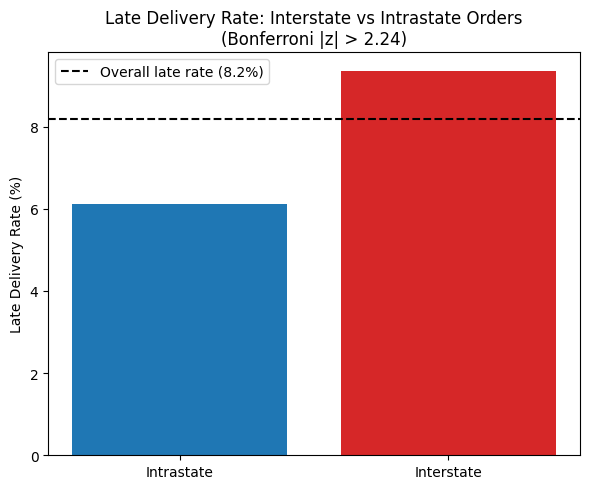

In [27]:
late_rate = (df_summary.loc['Late'] / df_summary.sum()) * 100
overall_late_rate = unique['is_late'].mean() * 100
k = len(df_summary.columns)
z_crit = stats.norm.ppf(1 - 0.05 / (2 * k))
z_vals = z_scores.loc['Late']
sig = z_vals.abs() > z_crit
colors = ['#d62728' if (s and z > 0) else ('#1f77b4' if (s and z < 0) else '#7f7f7f') for s, z in zip(sig, z_vals)]
labels = ['Interstate' if c else 'Intrastate' for c in late_rate.index]

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(labels, late_rate.values, color=colors)
ax.axhline(overall_late_rate, color='black', linestyle='--', label=f'Overall late rate ({overall_late_rate:.1f}%)')
ax.set_ylabel('Late Delivery Rate (%)')
ax.set_title(f'Late Delivery Rate: Interstate vs Intrastate Orders\n(Bonferroni |z| > {z_crit:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

### **1.1.6 State to State on late delivery**

In [28]:
unique['route'] = unique['seller_geo_state'] + '_to_' + unique['customer_geo_state']

route_matrix = unique.groupby('route', observed=False).agg(
    total_orders=('is_late', 'count'),
    late_orders=('is_late', 'sum')
).reset_index()

route_matrix['late_rate_pct'] = (route_matrix['late_orders'] / route_matrix['total_orders']) * 100

min_order_threshold = 50
filtered_routes = route_matrix[route_matrix['total_orders'] >= min_order_threshold]

print("--- Top 10 Worst Major Routes by Late Rate ---")
print(filtered_routes.sort_values(by='late_rate_pct', ascending=False).head(10))

--- Top 10 Worst Major Routes by Late Rate ---
        route  total_orders  late_orders  late_rate_pct
377  SP_to_AL           249           66      26.506024
139  MA_to_SP           117           31      26.495726
385  SP_to_MA           478          104      21.757322
278  RJ_to_CE            57           12      21.052632
392  SP_to_PI           325           60      18.461538
250  PR_to_BA           143           24      16.783217
400  SP_to_SE           205           34      16.585366
150  MG_to_MA            61           10      16.393443
394  SP_to_RJ          7985         1259      15.767063
381  SP_to_CE           945          147      15.555556


Now that we have made route of delivery from seller state to customer state, we will check the distribution but before that we would take only the major route in which have order more than 100.

In [29]:
major_routes = unique["route"].value_counts()[lambda x: x >= 100]

columns = major_routes.index
index = ["Late", "On-Time"]
late = []
on_time = []

for i in columns:
    late.append(unique[(unique['is_late']==True)&(unique['route']==i)]['order_id'].count())
    on_time.append(unique[(unique['is_late']==False)&(unique['route']==i)]['order_id'].count())

data = np.array([late, on_time])

df_summary = pd.DataFrame(data, index=index, columns=columns)

print("--- Contingency Table ---")
print(df_summary)

--- Contingency Table ---
route    SP_to_SP  SP_to_RJ  SP_to_MG  SP_to_RS  SP_to_PR  PR_to_SP  MG_to_SP  \
Late         1898      1259       468       271       167       105       109   
On-Time     28185      6726      6781      3232      2865      2819      2449   

route    SP_to_SC  SP_to_BA  MG_to_MG  SP_to_ES  SP_to_GO  SC_to_SP  SP_to_DF  \
Late          256       340        47       205       129        58       113   
On-Time      2007      1921      1479      1232      1256      1299      1236   

route    RJ_to_SP  MG_to_RJ  SP_to_PE  RJ_to_RJ  PR_to_RJ  SP_to_CE  PR_to_MG  \
Late          123       106       121        63       135       147        43   
On-Time      1224      1036       987       909       834       798       772   

route    PR_to_PR  SP_to_PA  RS_to_SP  SP_to_MT  PR_to_RS  RJ_to_MG  SC_to_RJ  \
Late           30        87        14        44        32        42        48   
On-Time       683       581       639       592       550       520       430   

In [30]:
chi2, p_val, dof, expected = stats.chi2_contingency(df_summary)

print("--- Chi-Square Test Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

--- Chi-Square Test Results ---
Chi-Square Statistic: 2024.3745
p-value: 0.000000
Degrees of Freedom: 69


With a Chi-Square p-value of **0.000000**, we have confirmed a significant correlation between seller state to customer state and delivery delays. and for that reason a deeper post-hoc test using **Z-scores (Adjusted Standardized Residuals)** is required to pinpoint exactly intrastate or interstate delivery that is causing the problem.

In [31]:
n = data.sum()

row_totals = df_summary.sum(axis=1).values[:, np.newaxis]  
col_totals = df_summary.sum(axis=0).values 

r_prop = row_totals / n
c_prop = col_totals / n

se = np.sqrt(expected * (1 - r_prop) * (1 - c_prop))

z_scores_matrix = (df_summary.values - expected) / se
z_scores = pd.DataFrame(z_scores_matrix, index=index, columns=columns)

print("--- Adjusted Residuals (Z-Scores) ---")
print(z_scores.round(2))

--- Adjusted Residuals (Z-Scores) ---
route    SP_to_SP  SP_to_RJ  SP_to_MG  SP_to_RS  SP_to_PR  PR_to_SP  MG_to_SP  \
Late       -14.21     26.13     -5.46     -0.88     -5.39     -9.14     -7.27   
On-Time     14.21    -26.13      5.46      0.88      5.39      9.14      7.27   

route    SP_to_SC  SP_to_BA  MG_to_MG  SP_to_ES  SP_to_GO  SC_to_SP  SP_to_DF  \
Late          5.6     12.16     -7.29      8.57      1.62     -5.24      0.33   
On-Time      -5.6    -12.16      7.29     -8.57     -1.62      5.24     -0.33   

route    RJ_to_SP  MG_to_RJ  SP_to_PE  RJ_to_RJ  PR_to_RJ  SP_to_CE  PR_to_MG  \
Late         1.35      1.43      3.41      -1.9      6.63      8.39      -3.0   
On-Time     -1.35     -1.43     -3.41       1.9     -6.63     -8.39       3.0   

route    PR_to_PR  SP_to_PA  RS_to_SP  SP_to_MT  PR_to_RS  RJ_to_MG  SC_to_RJ  \
Late        -3.85      4.64     -5.62     -1.13     -2.34     -0.58      1.53   
On-Time      3.85     -4.64      5.62      1.13      2.34      0.58 

Based on the adjusted standardized residuals for seller-to-customer state routes, we can draw the following conclusions:  
  
**Significantly Overrepresented in Late Deliveries (Z > +1.96)**  
- **SP to RJ (26.13)**: Holds the most extreme positive score, marking it as the absolute highest-risk bottleneck for delays.
- **Outbound SP to distant states**: Routes like SP to BA (12.16), SP to MA (10.92), SP to AL (10.62), SP to ES (8.57), and SP to CE (8.39) show heavy delay trends.
- **Other notable late routes**: MA to SP (7.27), SP to PI (6.82), PR to RJ (6.63), SP to SC (5.60), and SP to MS (5.35) significantly exceed the threshold.  
  
**Significantly Overrepresented in On-Time Deliveries (Z < -1.96)**  
- **SP to SP (-14.21)**: Heavily favors on-time completion, confirming intra-state delivery efficiency in São Paulo.
- **Commuter routes to SP**: Shipments coming into São Paulo like PR to SP (-9.14), MG to SP (-7.27), RS to SP (-5.62), and SC to SP (-5.24) are highly optimized and reliably fast.
- **Key Southeast/South pairings**: High efficiency is seen between regional hubs like MG to MG (-7.29), SP to MG (-5.46), SP to PR (-5.39), and MG to PR (-4.34).  
  
**Statistically Insignificant Routes (Within ±1.96)**  
- **Major local routes**: RJ to RJ (-1.90), RS to RS (-1.79), and SC to SC (-1.20) fall within normal variances.
- **Cross-regional routes**: SP to RS (-0.88), SP to DF (0.33), RJ to SP (1.35), and MG to RJ (1.43) show no predictable impact on delivery lateness.

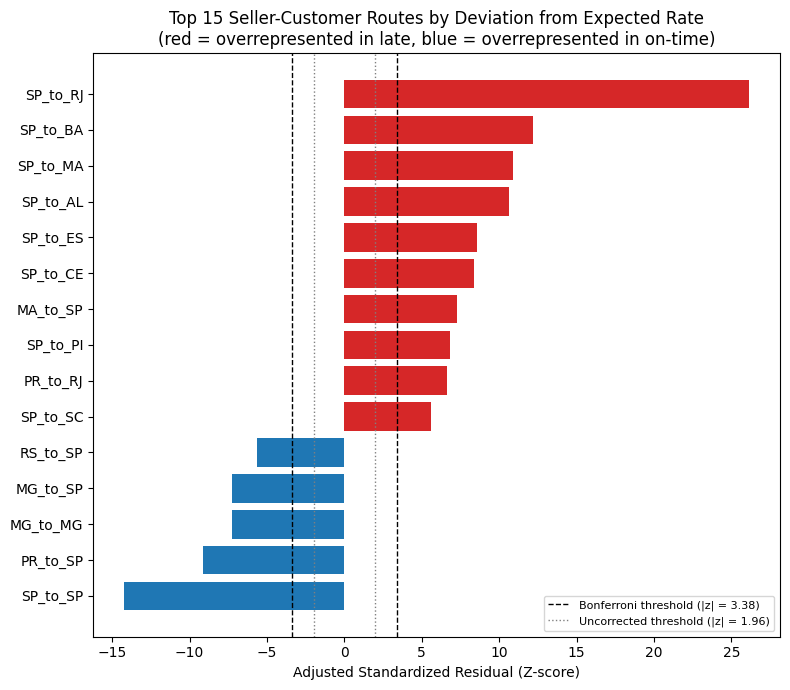

In [32]:
top_n = 15
z_late = z_scores.loc['Late']
k = len(df_summary.columns)
z_crit = stats.norm.ppf(1 - 0.05 / (2 * k)) 
top_routes = z_late.abs().sort_values(ascending=False).head(top_n).index
plot_data = z_late[top_routes].sort_values()
colors = ['#d62728' if v > 0 else '#1f77b4' for v in plot_data.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.axvline(z_crit, color='black', linestyle='--', linewidth=1, label=f'Bonferroni threshold (|z| = {z_crit:.2f})')
ax.axvline(-z_crit, color='black', linestyle='--', linewidth=1)
ax.axvline(1.96, color='grey', linestyle=':', linewidth=1, label='Uncorrected threshold (|z| = 1.96)')
ax.axvline(-1.96, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Adjusted Standardized Residual (Z-score)')
ax.set_title(f'Top {top_n} Seller-Customer Routes by Deviation from Expected Rate\n(red = overrepresented in late, blue = overrepresented in on-time)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()